# Prepare the data 

The below cell prepares the demo data and functions. It need to be run first!
Press **Enter + Shift** to execute the cell. You can also select the cell with cursor and click play button from the navigation bar as shown in the image below.

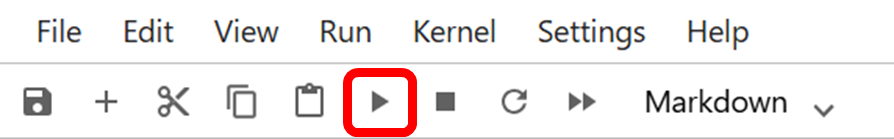

In [5]:
# First we load all the needed libraries
import os                # system library
import gensim            # NLP library for document/semantic analysis
import zipfile           # library for operations on zip files
import urllib.request    # library we use to download dataset

import numpy as np                       # library for numerical calculations
import plotly.express as px              # plotting library
import plotly.graph_objects as go        # plotting library
from sklearn.decomposition import PCA    # library to produce 2D representations of vectors

import random                           # random number generator
from sklearn.manifold import TSNE       # library to produce 2D representations of vectors
from sklearn.cluster import KMeans      # clustering function

import joblib       # library for saving and reading binary data

# First we check if model .bin file already exists. 
# Download or unzip it when needed.
if os.path.exists('en.bin') == False:
    if os.path.exists('12.zip') == False:
        # Download the data from URL
        url = "http://dl.turkunlp.org/TKO_7095_2023/12.zip"
        urllib.request.urlretrieve(url, "12.zip")
    elif os.path.exists('12.zip') == True:
        # If zip already exists, unzip
        with zipfile.ZipFile("12.zip", "r") as zip_ref:
            zip_ref.extractall(".")
    # Rename model.bin -> en.bin
    os.rename("model.bin", "en.bin")

# Ex 1 - word math

In this exercise we are using pre-computed embedding vectors obtained from word2vec model

In [140]:
# now we are loading the embeddings from downloaded model
from gensim.models import KeyedVectors
path = r"en.bin"
wv_emb_en=KeyedVectors.load_word2vec_format(path, limit=2500000, binary=True) # We retreive all the vectors in the simple model

We will play with embedding vectors and "word math" - to see how simple models associate words. In the below example you can see how model finds relation between words by simply adding and subtracting the vectors.
  
Word2 - Word1  + Word3  = ___?  
Paris - France + Sweden = ___?  
  
i.e. France is to Paris as Sweden is to X

In [117]:
# Function to print out the top n-th most similar word.
# Remember that in Python we start counting not from 1, but from 0 :)
def word_association(w1,w2,w3,n=0):
    """
    w1, w2, w3 - Word1 is to Word2 as Word3 to Result
    n          - n-th most similar word. 0 by defaul, retreives the most similar word.
                 to retreive 2nd most similar word change n to 1.
    """
    res = wv_emb_en.most_similar(positive=[w2,w3],negative=[w1])
    print(f"{w1} is to {w2} as {w3} is to {res[n][0]}")


word1 = "France"
word2 = "Paris"
word3 = "Sweden"
word_association(word1,word2,word3)

France is to Paris as Sweden is to Stockholm


In the below type your own examples! Try to see what happens when you change n from 0 to 1, 2, 3...  
**Question**: What happens when you change word capitalization? 🤔 

In [122]:
word1 = "car"
word2 = "road"
word3 = "pedestrian"
word_association(word1,word2,word3,n=0)

car is to road as pedestrian is to roadway


In the below example you see that word math not always works

In [250]:
triples=[("cow","milk","hen"),
         ("Paris","France","Helsinki"),
         ("car","wheel","airplane"),
         ("airplane","propeller","ship"),
         ("king","queen","man"),
         ("man","boss","woman"),
         ("mouse","cheese","bird"),
         ]
for what,is_to_what,as_this_is in triples:
    word_association(what,is_to_what,as_this_is)

cow is to milk as hen is to sauce
Paris is to France as Helsinki is to Finland
car is to wheel as airplane is to rudder
airplane is to propeller as ship is to vessel
king is to queen as man is to woman
man is to boss as woman is to bosses
mouse is to cheese as bird is to mozzarella


# EX 2 - vector relations

Since word embeddings are just vectors we can visualize them on 2D plots.
The cell below contains function that plots the vectors. Execute it with **Shift + Enter** to load the function, and then execute cell below!  
**Question**: Do you expect that the vector plots will follow the mathematic rules of vector addition? 🤔

In [245]:
def plot_word_analogy(wv, w1, w2, w3):
    # --- 1) Compute predicted word ---
    result = wv.most_similar(positive=[w2, w3], negative=[w1])
    w4 = result[0][0]

    print(f"{w1} is to {w2} as {w3} is to {w4}")

    # --- 2) Get vectors ---
    words = [w1, w2, w3, w4]
    vectors = np.array([wv[word] for word in words])

    # --- 3) Reduce to 2D with PCA ---
    pca = PCA(n_components=2)
    vectors_2d = pca.fit_transform(vectors)

    # Map words → coordinates
    coords = {word: vectors_2d[i] for i, word in enumerate(words)}

    # --- 4) Create scatter plot ---
    fig = go.Figure()

    # Points
    fig.add_trace(go.Scatter(
        x=vectors_2d[:, 0],
        y=vectors_2d[:, 1],
        mode='markers+text',
        text=words,
        textposition="top center",
        marker=dict(size=10),
        name="Words"
    ))

    # --- 5) Add arrows (vector relationships) ---
    def add_arrow(start, end, name):
        fig.add_annotation(
            x=end[0], y=end[1],
            ax=start[0], ay=start[1],
            xref='x', yref='y',
            axref='x', ayref='y',
            showarrow=True,
            arrowhead=2,
            arrowsize=2,
            arrowwidth=2,
            opacity=0.8,
            text=name
        )

    # w1 → w2 (base relation)
    add_arrow(coords[w1], coords[w2], f"{w1} → {w2}")

    # w3 → w4 (analogy result)
    add_arrow(coords[w3], coords[w4], f"{w3} → {w4}")

    # Optional: show vector transfer explicitly
    # w2 - w1 applied to w3
    add_arrow(coords[w2], coords[w3], "")  # visual connection

    # --- 6) Layout ---
    fig.update_layout(
        title=f"Word Analogy: {w1}:{w2} :: {w3}:{w4}",
        width=700,
        height=600,
        showlegend=False
    )
    fig.show()

In [ ]:
plot_word_analogy(wv_emb_en, "France", "Paris", "Sweden")

Try different combinations e.g those below, or try to come up with your own!
- "man", "uncle", "woman"
- "mouse", "cat", "dog"
- "woman", "mother", "man"
- "man", "woman", "Rick"

In [ ]:
# Remember to type words inside " " symbols!
w1 =
w2 =
w3 =
plot_word_analogy(wv_emb_en, w1, w2, w3)

What did you observed? Did all the examples made sense, or was there something that surprised you?  
**Question**: What can be the reason that some examples did not work? 🤔

# EX3 - visualizing the word space

The word embeddings we used in the previous two exercises have 300 dimensions, and under normal conditions - cannot be visualized in a way human would understand. However, some mathematical techniques enable us to see low dimensional representation - a projection of 300 dimensional object into 2D space.  
  
Such projections enable us to study how language space is arranged. In this exercise we will use such visualization technique. Execute the cell below to load visualization function!

In [ ]:
L = len(wv_emb_en) # length of the embeding list
keys = [wv_emb_en.index_to_key[i] for i in range(L)] # list of words

def plot_tsne_embeddings(embeddings, words, sample_size=3000, random_seed=42, nclusters=10, sample=False):
    # 1) Sample random subset
    random.seed(random_seed)

    # we can either sample random words from dataset (sample=True), or load entire set (sample=False)
    if sample == True:
        indices = random.sample(range(len(words)), sample_size)
    
        sampled_embeddings = embeddings[indices]
        sampled_words = [words[i] for i in indices]
    else:
        sampled_embeddings = np.array(embeddings)
        sampled_words = words
    
    print(f"Sampled {len(sampled_words)} words")

    # 2) Run t-SNE
    # TSNE is dimension reduction algorithm which enables us to do 2D visualization of word space
    tsne = TSNE(
        n_components=2,             # number of plot dimensions. In here 2 -> 2D plot
        perplexity=50,              # number of nearest-neighboor datapoints used to project each point to lower dimension
        random_state=random_seed,   # random seed from which we initialize plot
        init="pca"                  # initialization method
    )

    embeddings_2d = tsne.fit_transform(sampled_embeddings)  # calculation of 2D representation

    kmeans = KMeans(n_clusters=nclusters, random_state=0)   # clustering and labeling 2D representations
    labels = kmeans.fit_predict(sampled_embeddings)

    # 3) Prepare plot
    # Below function generates 2D plot. We enable look-up of plotted words by passing "sampled_words" to "hover_name" argument
    fig = px.scatter(
        x=embeddings_2d[:, 0],
        y=embeddings_2d[:, 1],
        color=labels,
        hover_name=sampled_words,
        title="t-SNE visualization of word embeddings"
    )

    fig.update_traces(marker=dict(size=6))
    fig.update_layout(
        width=800,
        height=600
    )

    fig.show()


# ==========================
# Execute plotting function!
plot_tsne_embeddings(wv_emb_en, keys,sample=True,nclusters=12)

Did you notice anything interesting in the map of words? Are there any grouping of similar words? What are the similarities?  
  
In the function above, we sampled random words. But how about sampling selected groups of words?  
Below you can find the function which selects clusters of words which are most similar to given keyword. Observe how this affects the plot.  
We assume that the number of observed clusters will be the same as number of keywords.  

**Question**: Under what conditions you expect to not observe distinct clusters of words? 🤔

In [ ]:
def plot_clusters(keywords,top=50):
    """
    keywords - your list of words
    top      - number of most similar words to selected keywords
    """
    words = []
    for c in keywords:
        words.append(c)
        for em in wv_emb_en.similar_by_word(c,topn=top):
            words.append(em[0])
    unique_words = list(set(words))
    unique_embd = [wv_emb_en.get_vector(i) for i in unique_words]

    plot_tsne_embeddings(unique_embd,unique_words,sample_size=len(unique_words),sample=False)

clusters = ['country','food','metal','car','animal','river','activity','planet','computer','date']
plot_clusters(clusters)

Try your own combination of keywords! Fill in the clusters variable below, remember to type keywords inside ' '

In [ ]:
clusters = ['','','','','','','']
plot_clusters(clusters)

# EX4 - embedding comparison

In [266]:
gpt2_embs = joblib.load("gpt2_embs.joblib")
gpt2_emb_norm = gpt2_embs / np.linalg.norm(gpt2_embs, axis=1, keepdims=True)

292479

In [159]:
def most_similar_gpt2(
    words,
    embeddings,
    positive=[],
    negative=[],
    topn=10
):
    # --- 1) Build query vector ---
    query = np.zeros(embeddings.shape[1])

    for w in positive:
        idx = words.index(w)
        query += embeddings[idx]

    for w in negative:
        idx = words.index(w)
        query -= embeddings[idx]

    # Normalize query
    query = query / np.linalg.norm(query)

    # --- 2) Cosine similarity (FAST) ---
    sims = embeddings @ query  # dot product

    # --- 3) Remove input words ---
    banned = set(positive + negative)
    for w in banned:
        if w in words:
            sims[words.index(w)] = -np.inf

    # --- 4) Get top results ---
    best_idx = np.argsort(-sims)[:topn]

    return [(words[i], float(sims[i])) for i in best_idx]

In [198]:
most_similar_gpt2(keys,gpt2_emb_norm,positive=['Paris','Sweden'],negative=['France'],topn=5)

[('Berat', 0.997553545140744),
 ('Ciel', 0.9974204799212214),
 ('Biel', 0.997382726966185),
 ('Essen', 0.9973227308010233),
 ('Graden', 0.9973215741992336)]

Sampled 500 words


C:\Users\togali\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.



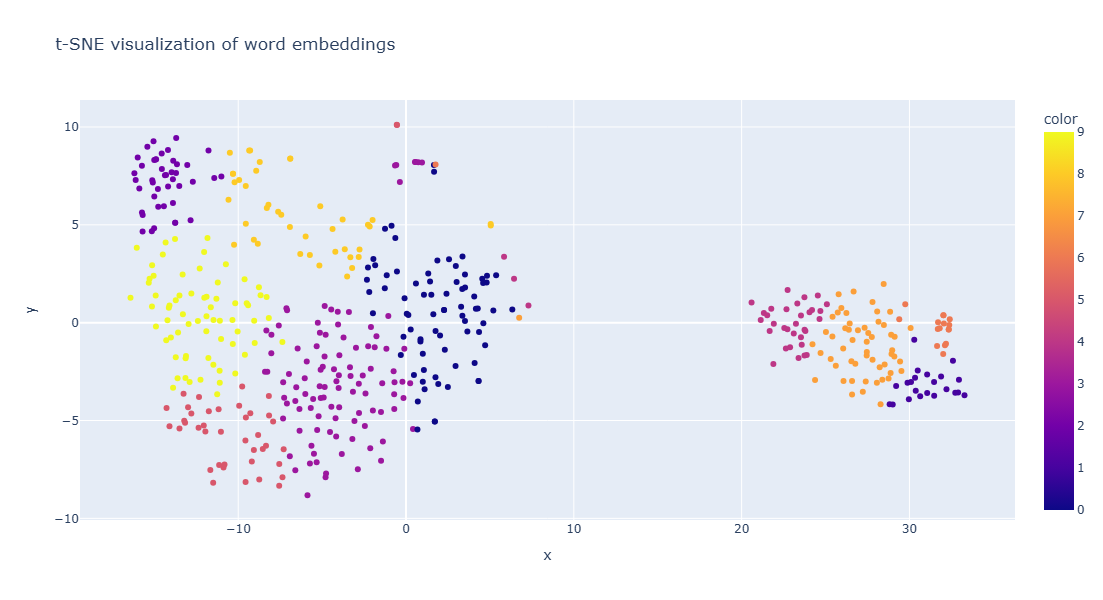

In [217]:
import random
idx = [random.randint(0,20000) for i in range(500)]
plot_tsne_embeddings(gpt2_emb_norm[idx], np.array(keys)[idx],sample=False)

Sampled 500 words


C:\Users\togali\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.



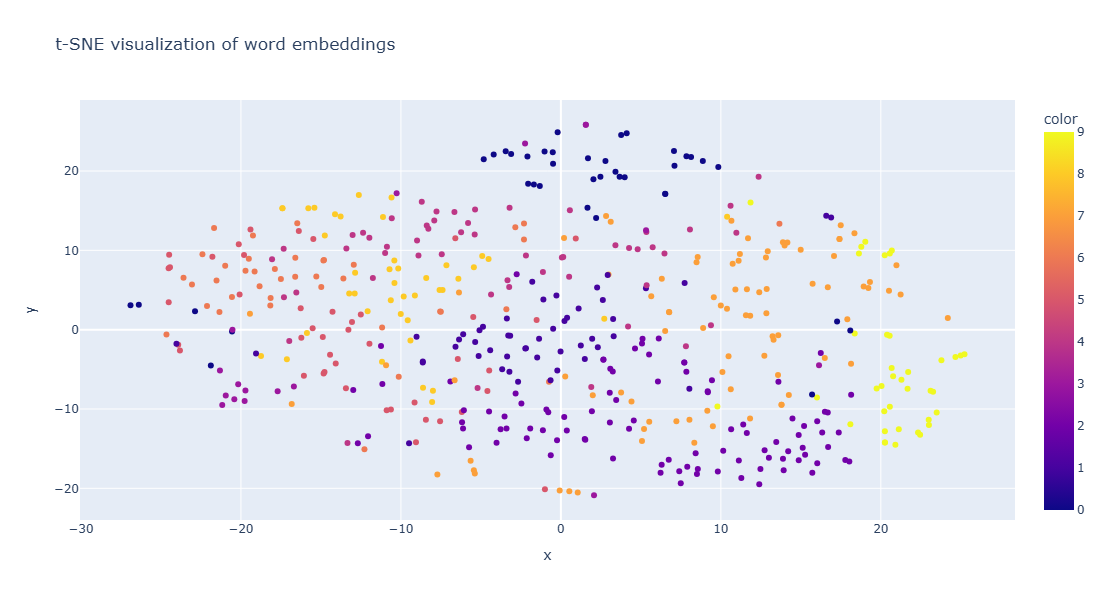

In [218]:
plot_tsne_embeddings(wv_emb_en[idx], np.array(keys)[idx],sample=False)